# Anindya Biswas
## UG-2, Physics
## Roll No: 002420701050
## Problem Set 4

## Applications of numpy/scipy modules

### 1. Projectile Motion Problem (Root Finding): A ball is launched with an initial speed v=50 m/s at an angle θ=45∘ from the ground. Find the time when the ball hits the ground. Equation to Solve: 
### y(t)=v*t*sin(θ)−0.5*g*t^2=0 
### g=9.8 m/s^2

In [8]:
import numpy as np
from scipy.optimize import root_scalar
v=50
theta=np.radians(45)
g=9.8

def f(t):
    return v*t*np.sin(theta)-0.5*g*t**2
    
def f_prime(t):
    return v*np.sin(theta)-g*t
    
sol_new=root_scalar(f,fprime=f_prime,x0=5.0, method="newton")
sol_bisec=root_scalar(f,bracket=[1,10], method="bisect")

print("The solution by Newton-Raphson Method: ",sol_new)
print("The solution by Bisection Method: ",sol_bisec)

The solution by Newton-Raphson Method:        converged: True
           flag: converged
 function_calls: 12
     iterations: 6
           root: 7.215375318230076
         method: newton
The solution by Bisection Method:        converged: True
           flag: converged
 function_calls: 45
     iterations: 43
           root: 7.215375318229803
         method: bisect


### 2. Radioactive Decay Problem (ODE Solving): A radioactive substance A decays into a stable substance B with a decay constant λ=0.5 per day. If initially there are 1000 atoms of A, find how the number of atoms of A after 1, 5 and 10 days.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
def f(t,N,lam):
    return -lam*N
t_span=(0,10)
N0=[1000.0]
lam_constant=0.5

t_point=[1,5,10]

sol=solve_ivp(f,t_span,N0,args=(lam_constant,),t_eval=t_point)

n_val=sol.y[0]
n1=n_val[0]
n2=n_val[1]
n3=n_val[2]
print("For Day 1: ","Remaining atoms=",n1,"\nFor Day 5: ","Remaining atoms=",n2,"\nFor Day 10: ","Remaining atoms=",n3)

For Day 1:  Remaining atoms= 606.526854165098 
For Day 5:  Remaining atoms= 82.1664777982317 
For Day 10:  Remaining atoms= 6.753896700516714


### 3. Integration Problem: A particle moves along a straight line under a variable force F(x)=5*x^2 N. Calculate the work done by the force as the particle moves from x=0 to x=4 meters.
### Hint: Work done

In [32]:
import scipy.integrate as integ
def f(x):
    return 5*x*x
a=0
b=4
ans=integ.quad(f,a,b)
print("Work Done is:",ans[0],"Joule","\nEsteemated error is :",ans[1] )

Work Done is: 106.66666666666666 Joule 
Esteemated error is : 1.1842378929335002e-12


### 4. Compute and plot the spectral radiance of a blackbody as a function of wavelength at different temperatures (3000, 5000, 10000 K) using Planck's law (use numpy modules such as numpy.linspace, numpy.exp, numpy.power etc) 

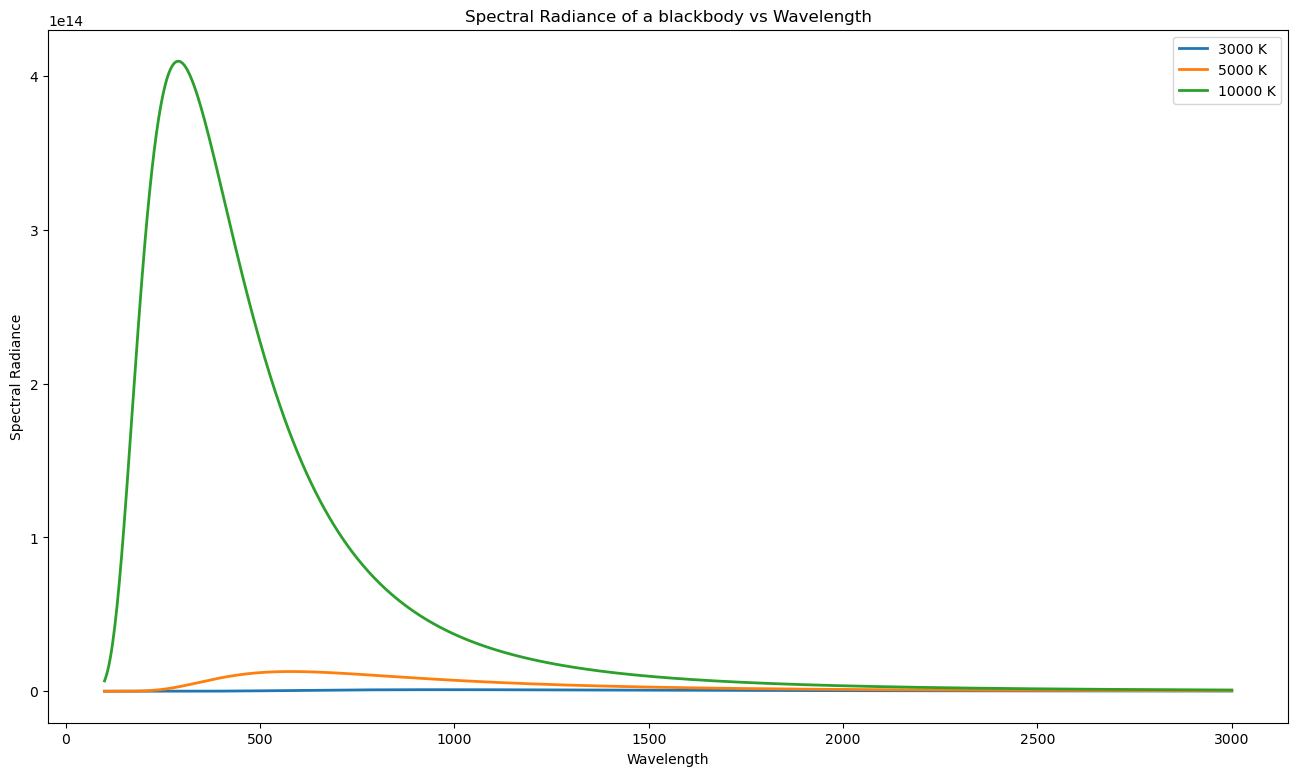

In [57]:
import numpy as np
from scipy.constants import Boltzmann,Planck,speed_of_light
import matplotlib.pyplot as plt
k=Boltzmann
h=Planck
c=speed_of_light
temp=[3000,5000,10000]
lam=np.linspace(100e-9,3000e-9,1000)
plt.figure(figsize=(16,9))
for t in temp:
    fx=(2*h*c**2*lam**(-5))*(np.exp((h*c)/(lam*k*t))-1)**(-1)
    plt.plot(lam*1e9,fx,label=f"{t} K",linewidth=2,linestyle="-")
plt.xlabel("Wavelength")
plt.ylabel("Spectral Radiance")
plt.title("Spectral Radiance of a blackbody vs Wavelength")
plt.legend()
plt.show()


### 5. Use the scipy module “scipy.optimize.curve_fit” to fit a data with a given curve.
### [Choose your own data set and the function]

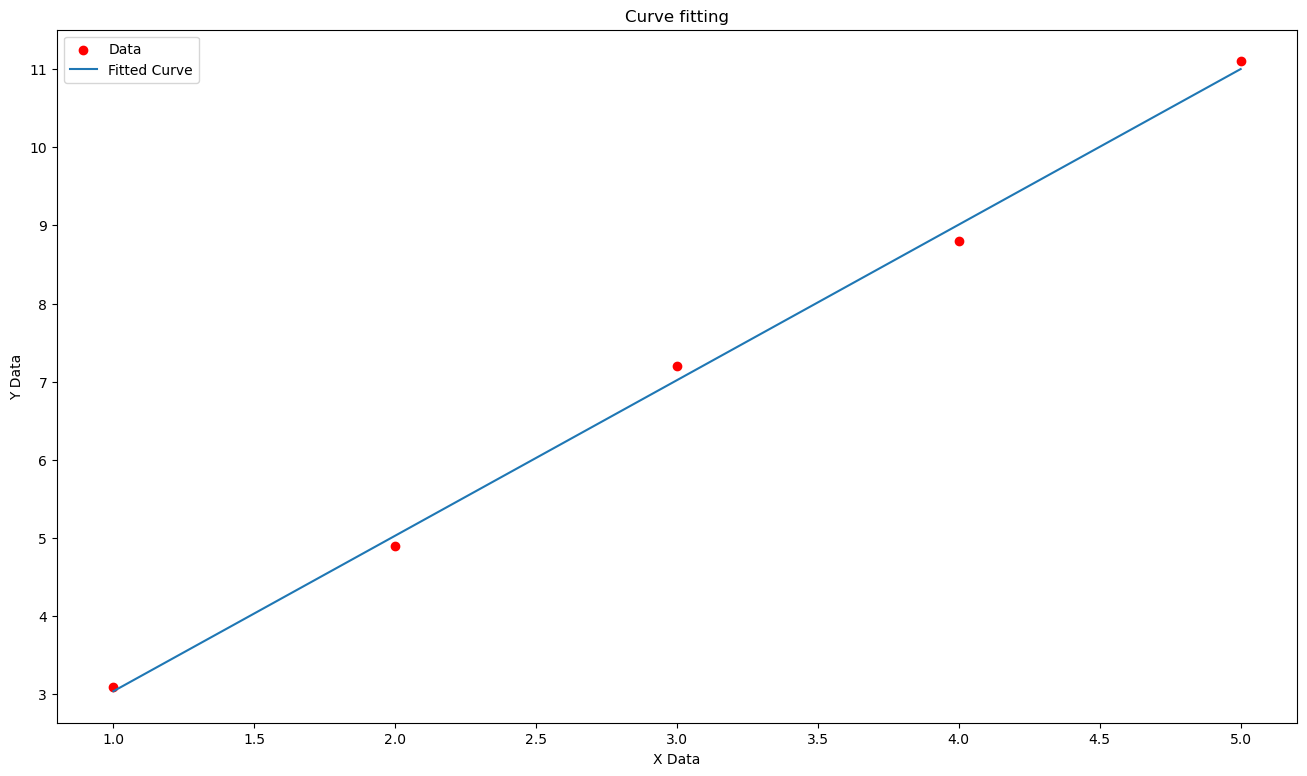

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
xdata=[1, 2, 3, 4, 5]
ydata=[3.1, 4.9, 7.2, 8.8, 11.1]
def f(x,m,c):
    return m*x+c
popt, pcov = curve_fit(f,xdata,ydata)
plt.figure(figsize=(16,9))
tdata=np.array([1, 2, 3, 4, 5])
yfit=f(tdata, *popt)
plt.scatter(xdata,ydata,label="Data",color="red")
plt.plot(tdata,yfit, label="Fitted Curve")
plt.legend()
plt.xlabel("X Data")
plt.ylabel("Y Data")
plt.title("Curve fitting")
plt.show()